# Portfolio Project: Automobile Price Analysis and Regression Modeling 

---

# 05 — Regression Model Evaluation & Selection
## Automobile Pricing Analytics

### Analytical purpose
Notebook 04 developed several regression specifications and compared their **in-sample fit**. This final notebook asks a more important question:

> **How well do those regression models generalize to observations that were not used to estimate them?**

### Objectives
1. Separate the data into training and holdout testing samples.
2. Compare the regression specifications developed in Notebook 04 using **cross-validation**.
3. Examine training-versus-testing performance to identify overfitting.
4. Evaluate how polynomial degree affects generalization.
5. Compare final holdout performance using **R², RMSE, and MAE**.
6. Select a final regression specification based on both predictive performance and parsimony.

### Models carried forward from Notebook 04
- **SLR — Highway MPG**
- **SLR — Engine Size**
- **MLR — Horsepower + Curb Weight + Engine Size + Highway MPG**
- **Polynomial Regression — Highway MPG**

## 1. Setup and load the cleaned dataset

The same analysis-ready dataset used in Notebooks 03 and 04 is loaded here. No new cleaning or feature engineering is performed.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

candidate_paths = [
    Path("../data/auto_cleaned.csv"),
    Path("data/auto_cleaned.csv"),
    Path("auto_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "auto_cleaned.csv was not found. Run Notebook 02 first or place the file "
        "in ../data/, data/, or the current directory."
    )

df = pd.read_csv(data_path)

print(f"Dataset location: {data_path.resolve()}")
print(f"Shape: {df.shape}")

Dataset location: /mnt/data/auto_cleaned.csv
Shape: (201, 29)


In [2]:
required_columns = {
    "price", "highway-mpg", "engine-size",
    "horsepower", "curb-weight"
}

missing = required_columns.difference(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"
assert df[list(required_columns)].notna().all().all()

df[list(required_columns)].head()

,curb-weight,engine-size,horsepower,price,highway-mpg
0,2548,130,111.000,"13,495.000",27
1,2548,130,111.000,"16,500.000",27
2,2823,152,154.000,"16,500.000",26
3,2337,109,102.000,"13,950.000",30
4,2824,136,115.000,"17,450.000",22


## 2. Evaluation design

A single train/test split is created and then held fixed for the entire notebook.

- **Training set (80%)**: used to estimate models and perform cross-validation.
- **Test set (20%)**: held out until final evaluation.

This separation avoids judging a model primarily on the same observations used to fit it.

Because the dataset is relatively small, a single test score can still be sensitive to the particular split. Therefore, **5-fold cross-validation on the training sample** is used as an additional measure of model stability.


In [3]:
target = df["price"]

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

print(f"Training observations: {len(train_df)}")
print(f"Testing observations:  {len(test_df)}")
print(f"Training proportion:   {len(train_df) / len(df):.1%}")
print(f"Testing proportion:    {len(test_df) / len(df):.1%}")

Training observations: 160
Testing observations:  41
Training proportion:   79.6%
Testing proportion:    20.4%


## 3. Evaluation metrics

Three primary metrics are used:

- **R²**: proportion of price variation explained by the model. Higher is better.
- **RMSE**: root mean squared error, measured in dollars. It penalizes large errors relatively strongly.
- **MAE**: mean absolute error, also measured in dollars. It is easier to interpret as the average absolute prediction error.

A model is not selected from one metric alone. Generalization, consistency, model complexity, and interpretability are considered together.


In [4]:
def evaluate_predictions(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


def fit_and_evaluate(model, features, train_data, test_data):
    X_train = train_data[features]
    y_train = train_data["price"]
    X_test = test_data[features]
    y_test = test_data["price"]

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return (
        evaluate_predictions(y_train, train_pred),
        evaluate_predictions(y_test, test_pred),
        train_pred,
        test_pred,
    )

# Part I — Training and Holdout Testing

## 4. Re-estimate the candidate models

The same model definitions developed in Notebook 04 are fitted using only the training sample.


In [5]:
model_specs = {
    "SLR — Highway MPG": {
        "model": LinearRegression(),
        "features": ["highway-mpg"],
    },
    "SLR — Engine Size": {
        "model": LinearRegression(),
        "features": ["engine-size"],
    },
    "MLR — 4 Predictors": {
        "model": LinearRegression(),
        "features": [
            "horsepower",
            "curb-weight",
            "engine-size",
            "highway-mpg",
        ],
    },
    "Polynomial — Highway MPG (degree 3)": {
        "model": Pipeline([
            ("polynomial_features", PolynomialFeatures(
                degree=3,
                include_bias=False
            )),
            ("linear_regression", LinearRegression()),
        ]),
        "features": ["highway-mpg"],
    },
}

In [6]:
holdout_rows = []
predictions = {}

for name, spec in model_specs.items():
    train_metrics, test_metrics, train_pred, test_pred = fit_and_evaluate(
        spec["model"],
        spec["features"],
        train_df,
        test_df,
    )

    predictions[name] = {
        "train": train_pred,
        "test": test_pred,
    }

    holdout_rows.append({
        "Model": name,
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"],
        "Train RMSE": train_metrics["RMSE"],
        "Test RMSE": test_metrics["RMSE"],
        "Train MAE": train_metrics["MAE"],
        "Test MAE": test_metrics["MAE"],
    })

holdout_results = pd.DataFrame(holdout_rows).set_index("Model")
holdout_results

,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
Model,,,,,,
SLR — Highway MPG,0.501,0.425,"4,770.316","8,389.867","3,344.625","5,962.688"
SLR — Engine Size,0.757,0.725,"3,331.996","5,804.911","2,538.042","4,176.273"
MLR — 4 Predictors,0.809,0.764,"2,952.936","5,377.403","2,111.017","3,768.855"
Polynomial — Highway MPG (degree 3),0.693,0.601,"3,740.717","6,983.311","2,590.054","4,468.325"


### Training-versus-testing interpretation

Comparing training and testing performance helps identify whether additional model flexibility is translating into genuine generalization.

- A small train–test gap suggests that the model behaves similarly on observed and unseen data.
- A much better training score than testing score can indicate **overfitting**.
- Poor performance on both training and testing data can indicate **underfitting** or an overly restrictive specification.

The absolute size of these differences should be interpreted together with the small sample size.


In [7]:
gap_table = pd.DataFrame({
    "Train R2": holdout_results["Train R2"],
    "Test R2": holdout_results["Test R2"],
    "R2 Gap (Train - Test)": (
        holdout_results["Train R2"] - holdout_results["Test R2"]
    ),
    "Test RMSE": holdout_results["Test RMSE"],
    "Test MAE": holdout_results["Test MAE"],
}).sort_values("Test R2", ascending=False)

gap_table

,Train R2,Test R2,R2 Gap (Train - Test),Test RMSE,Test MAE
Model,,,,,
MLR — 4 Predictors,0.809,0.764,0.045,"5,377.403","3,768.855"
SLR — Engine Size,0.757,0.725,0.032,"5,804.911","4,176.273"
Polynomial — Highway MPG (degree 3),0.693,0.601,0.092,"6,983.311","4,468.325"
SLR — Highway MPG,0.501,0.425,0.077,"8,389.867","5,962.688"


# Part II — Cross-Validation

## 5. Why add cross-validation?

We introduce cross-validation because a single train/test split can give a noisy estimate when the dataset is small.

Here, 5-fold cross-validation is applied **only to the training sample**. Each candidate model is repeatedly fitted on four folds and evaluated on the remaining fold. The untouched holdout test set remains reserved for the final comparison.

This provides a more stable view of how each specification performs across different subsets of the available training data.


In [8]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "neg_mse": "neg_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
}

cv_rows = []

for name, spec in model_specs.items():
    X_train = train_df[spec["features"]]
    y_train = train_df["price"]

    scores = cross_validate(
        spec["model"],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
    )

    fold_rmse = np.sqrt(-scores["test_neg_mse"])
    fold_mae = -scores["test_neg_mae"]

    cv_rows.append({
        "Model": name,
        "CV Mean R2": scores["test_r2"].mean(),
        "CV R2 SD": scores["test_r2"].std(),
        "CV Mean RMSE": fold_rmse.mean(),
        "CV RMSE SD": fold_rmse.std(),
        "CV Mean MAE": fold_mae.mean(),
    })

cv_results = (
    pd.DataFrame(cv_rows)
      .set_index("Model")
      .sort_values("CV Mean R2", ascending=False)
)

cv_results

,CV Mean R2,CV R2 SD,CV Mean RMSE,CV RMSE SD,CV Mean MAE
Model,,,,,
MLR — 4 Predictors,0.767,0.078,"3,092.269",394.617,"2,196.588"
SLR — Engine Size,0.701,0.149,"3,381.019",354.837,"2,582.419"
Polynomial — Highway MPG (degree 3),0.617,0.184,"3,819.388",326.192,"2,665.192"
SLR — Highway MPG,0.444,0.110,"4,846.319",499.768,"3,382.662"


### Cross-validation interpretation

The **mean** cross-validation score reflects average performance across folds, while the **standard deviation** gives a simple indication of how sensitive the model is to different training subsets.

A model with slightly higher average R² but much greater variability may be less dependable than a simpler model with comparable average performance and greater stability.


# Part III — Polynomial Complexity and Overfitting

## 6. How much polynomial complexity is justified?

Notebook 04 used a cubic polynomial for `highway-mpg`. We will compare degrees **1 through 15** to identify the appropriate degree.

The purpose is not to maximize training fit. It is to identify where cross-validated performance reaches its best level and whether higher-order polynomials begin to overfit.

Degree 1 is equivalent to ordinary linear regression on highway MPG.

In [9]:
degree_rows = []

for degree in range(1, 16):
    model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),
        ("linear_regression", LinearRegression()),
    ])

    scores = cross_validate(
        model,
        train_df[["highway-mpg"]],
        train_df["price"],
        cv=cv,
        scoring=scoring,
        return_train_score=True,
    )

    degree_rows.append({
        "Degree": degree,
        "Mean Train R2": scores["train_r2"].mean(),
        "Mean CV R2": scores["test_r2"].mean(),
        "CV R2 SD": scores["test_r2"].std(),
        "Mean CV RMSE": np.sqrt(-scores["test_neg_mse"]).mean(),
        "Mean CV MAE": (-scores["test_neg_mae"]).mean(),
    })

degree_results = pd.DataFrame(degree_rows).set_index("Degree")
degree_results

,Mean Train R2,Mean CV R2,CV R2 SD,Mean CV RMSE,Mean CV MAE
Degree,,,,,
1,0.502,0.444,0.110,"4,846.319","3,382.662"
2,0.661,0.583,0.163,"4,057.450","2,777.817"
3,0.692,0.617,0.184,"3,819.388","2,665.192"
4,0.700,0.626,0.179,"3,768.742","2,655.358"
5,0.716,0.646,0.170,"3,670.128","2,495.767"
6,0.727,0.657,0.139,"3,668.618","2,501.407"
7,0.725,0.655,0.149,"3,662.506","2,531.103"
8,0.719,0.633,0.179,"3,729.575","2,590.008"
9,0.710,0.576,0.259,"3,914.951","2,690.941"


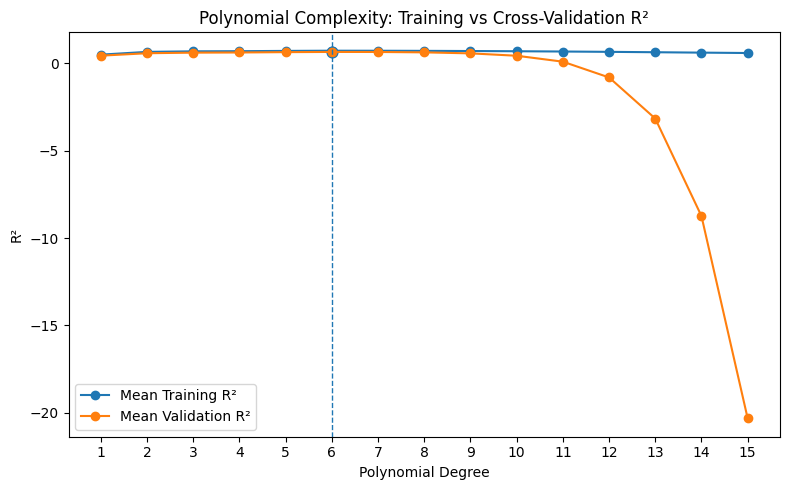

Best degree by mean CV R²: 6
Best mean CV R²: 0.6575


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    degree_results.index,
    degree_results["Mean Train R2"],
    marker="o",
    label="Mean Training R²",
)
ax.plot(
    degree_results.index,
    degree_results["Mean CV R2"],
    marker="o",
    label="Mean Validation R²",
)

best_degree = degree_results["Mean CV R2"].idxmax()
best_cv_r2 = degree_results.loc[best_degree, "Mean CV R2"]

ax.axvline(best_degree, linestyle="--", linewidth=1)
ax.scatter([best_degree], [best_cv_r2], s=60)

ax.set_title("Polynomial Complexity: Training vs Cross-Validation R²")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("R²")
ax.set_xticks(degree_results.index)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Best degree by mean CV R²: {best_degree}")
print(f"Best mean CV R²: {best_cv_r2:.4f}")

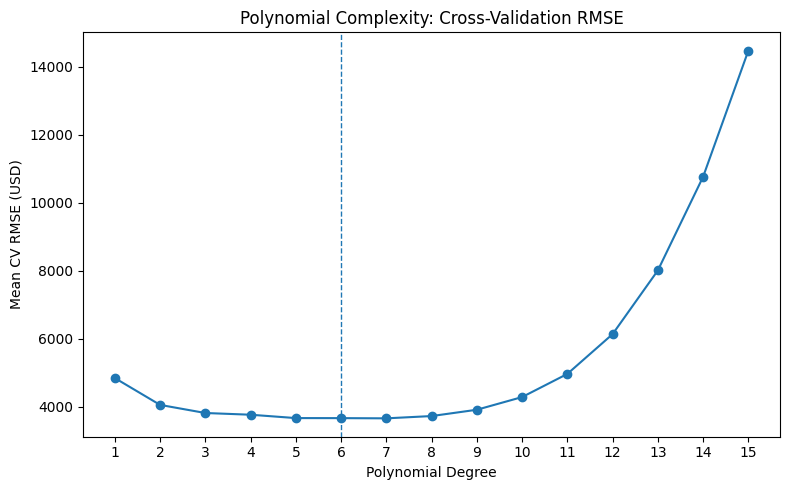

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    degree_results.index,
    degree_results["Mean CV RMSE"],
    marker="o"
)
ax.axvline(best_degree, linestyle="--", linewidth=1)
ax.set_title("Polynomial Complexity: Cross-Validation RMSE")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Mean CV RMSE (USD)")
ax.set_xticks(degree_results.index)
plt.tight_layout()
plt.show()

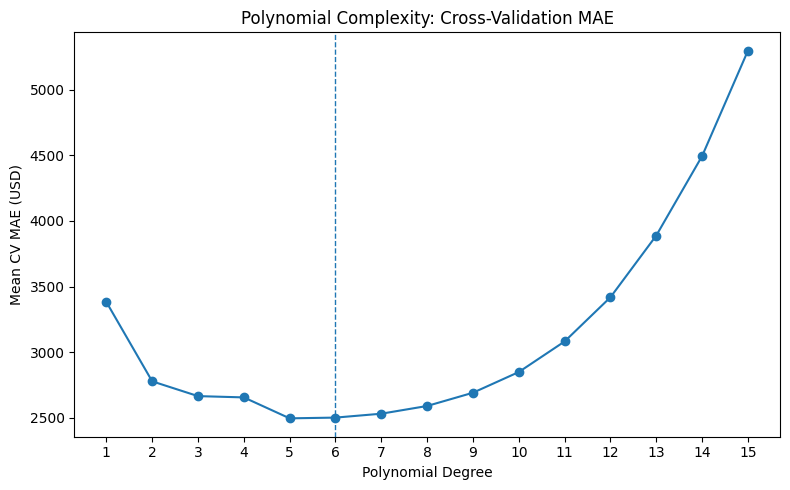

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    degree_results.index,
    degree_results["Mean CV MAE"],
    marker="o"
)
ax.axvline(best_degree, linestyle="--", linewidth=1)
ax.set_title("Polynomial Complexity: Cross-Validation MAE")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Mean CV MAE (USD)")
ax.set_xticks(degree_results.index)
plt.tight_layout()
plt.show()

### Overfitting interpretation

The degree search is interpreted using both **fit** and **generalization**:

- Training R² is expected to rise as polynomial degree increases because the model becomes more flexible.
- Cross-validation R² should rise only while that added flexibility captures stable structure in the data.
- Once validation R² stops improving or declines while training R² continues to rise, additional polynomial terms are fitting sample-specific noise.
- RMSE and MAE provide a second check: if they begin to worsen as degree increases, the extra complexity is not improving predictive accuracy.

The preferred degree is therefore based primarily on **cross-validated performance**, with stability and parsimony considered alongside the absolute best score.


In [13]:
best_row = degree_results.loc[best_degree]

print("Selected polynomial degree based on cross-validation:")
print(f"Degree: {best_degree}")
print(f"Mean CV R²: {best_row['Mean CV R2']:.4f}")
print(f"CV R² SD: {best_row['CV R2 SD']:.4f}")
print(f"Mean CV RMSE: ${best_row['Mean CV RMSE']:,.0f}")
print(f"Mean CV MAE: ${best_row['Mean CV MAE']:,.0f}")

Selected polynomial degree based on cross-validation:
Degree: 6
Mean CV R²: 0.6575
CV R² SD: 0.1390
Mean CV RMSE: $3,669
Mean CV MAE: $2,501


### Parsimony check

The degree with the highest mean validation R² is not automatically preferable if nearby lower-degree models perform nearly as well with substantially less complexity.

Accordingly, the selected polynomial should be interpreted in context:

- If the highest-scoring degree clearly outperforms simpler alternatives, that added flexibility is justified.
- If several neighboring degrees have nearly identical validation performance, the simpler specification may be preferable for interpretability and stability.

This keeps the analysis focused on regression reasoning rather than mechanical score maximization.


# Part IV — Final Holdout Evaluation

## 7. Refit the selected polynomial and compare models on the untouched test set

The polynomial degree has now been selected using cross-validation on the training data only.

The chosen polynomial is therefore refitted on the full training sample and evaluated **once** on the untouched holdout test set. This avoids using the test set as a model-selection tool.


In [14]:
# Refit the selected polynomial degree on the full training sample
selected_poly_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        degree=int(best_degree),
        include_bias=False
    )),
    ("linear_regression", LinearRegression()),
])

selected_poly_model.fit(
    train_df[["highway-mpg"]],
    train_df["price"]
)

selected_poly_train_pred = selected_poly_model.predict(
    train_df[["highway-mpg"]]
)
selected_poly_test_pred = selected_poly_model.predict(
    test_df[["highway-mpg"]]
)

selected_poly_train_metrics = evaluate_predictions(
    train_df["price"],
    selected_poly_train_pred
)
selected_poly_test_metrics = evaluate_predictions(
    test_df["price"],
    selected_poly_test_pred
)

# Build final holdout comparison with the selected polynomial replacing the fixed cubic model.
final_holdout_rows = []

for name, spec in model_specs.items():
    if name.startswith("Polynomial"):
        continue

    train_metrics, test_metrics, _, _ = fit_and_evaluate(
        spec["model"],
        spec["features"],
        train_df,
        test_df,
    )

    final_holdout_rows.append({
        "Model": name,
        "Test R2": test_metrics["R2"],
        "Test RMSE": test_metrics["RMSE"],
        "Test MAE": test_metrics["MAE"],
    })

final_holdout_rows.append({
    "Model": f"Polynomial — Highway MPG (degree {int(best_degree)})",
    "Test R2": selected_poly_test_metrics["R2"],
    "Test RMSE": selected_poly_test_metrics["RMSE"],
    "Test MAE": selected_poly_test_metrics["MAE"],
})

final_holdout = pd.DataFrame(final_holdout_rows).set_index("Model")

# Build corresponding CV comparison
cv_final_rows = []

for name, spec in model_specs.items():
    if name.startswith("Polynomial"):
        continue

    X_train = train_df[spec["features"]]
    y_train = train_df["price"]

    scores = cross_validate(
        spec["model"],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
    )

    cv_final_rows.append({
        "Model": name,
        "CV Mean R2": scores["test_r2"].mean(),
        "CV R2 SD": scores["test_r2"].std(),
        "CV Mean RMSE": np.sqrt(-scores["test_neg_mse"]).mean(),
        "CV Mean MAE": (-scores["test_neg_mae"]).mean(),
    })

cv_final_rows.append({
    "Model": f"Polynomial — Highway MPG (degree {int(best_degree)})",
    "CV Mean R2": best_row["Mean CV R2"],
    "CV R2 SD": best_row["CV R2 SD"],
    "CV Mean RMSE": best_row["Mean CV RMSE"],
    "CV Mean MAE": best_row["Mean CV MAE"],
})

cv_final = pd.DataFrame(cv_final_rows).set_index("Model")

final_comparison = (
    final_holdout
    .join(cv_final)
    .sort_values("Test R2", ascending=False)
)

final_comparison

,Test R2,Test RMSE,Test MAE,CV Mean R2,CV R2 SD,CV Mean RMSE,CV Mean MAE
Model,,,,,,,
MLR — 4 Predictors,0.764,"5,377.403","3,768.855",0.767,0.078,"3,092.269","2,196.588"
SLR — Engine Size,0.725,"5,804.911","4,176.273",0.701,0.149,"3,381.019","2,582.419"
Polynomial — Highway MPG (degree 6),0.546,"7,456.260","4,756.292",0.657,0.139,"3,668.618","2,501.407"
SLR — Highway MPG,0.425,"8,389.867","5,962.688",0.444,0.110,"4,846.319","3,382.662"


In [15]:
formatted_comparison = final_comparison.copy()

for column in ["Test R2", "CV Mean R2", "CV R2 SD"]:
    formatted_comparison[column] = formatted_comparison[column].round(4)

for column in ["Test RMSE", "Test MAE", "CV Mean RMSE", "CV Mean MAE"]:
    formatted_comparison[column] = formatted_comparison[column].round(0)

formatted_comparison

,Test R2,Test RMSE,Test MAE,CV Mean R2,CV R2 SD,CV Mean RMSE,CV Mean MAE
Model,,,,,,,
MLR — 4 Predictors,0.764,"5,377.000","3,769.000",0.767,0.078,"3,092.000","2,197.000"
SLR — Engine Size,0.725,"5,805.000","4,176.000",0.701,0.149,"3,381.000","2,582.000"
Polynomial — Highway MPG (degree 6),0.546,"7,456.000","4,756.000",0.657,0.139,"3,669.000","2,501.000"
SLR — Highway MPG,0.425,"8,390.000","5,963.000",0.444,0.110,"4,846.000","3,383.000"


## 8. Visual check of final test predictions

The observed-versus-predicted plots below provide a direct visual comparison of the candidate models on the holdout set. Predictions closer to the 45-degree reference line indicate better agreement with observed prices.


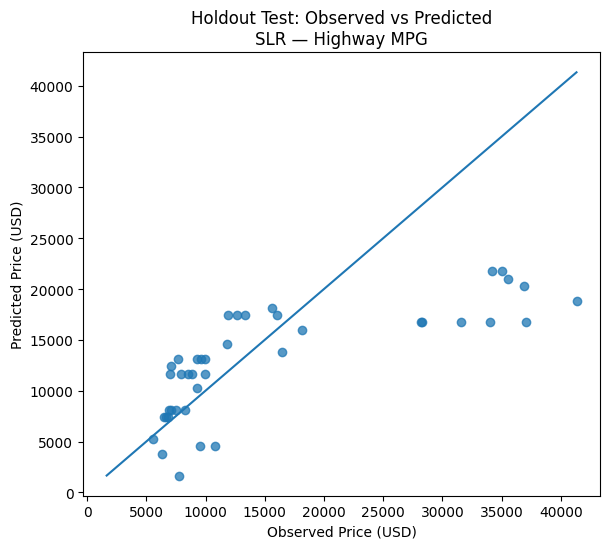

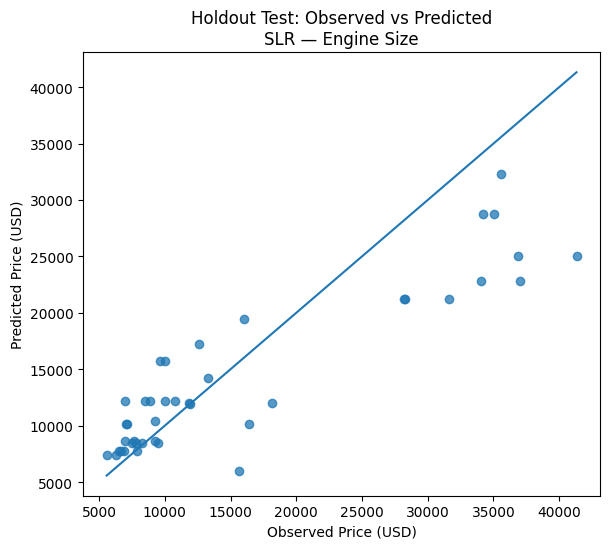

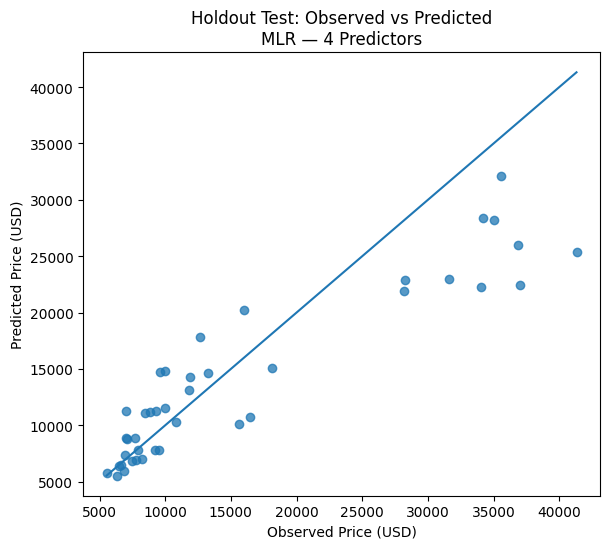

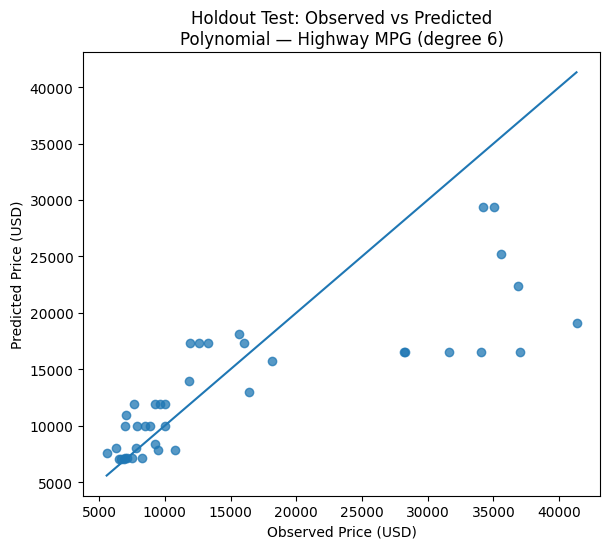

In [16]:
y_test = test_df["price"]

final_predictions = {}

# Refit and predict for non-polynomial models
for name, spec in model_specs.items():
    if name.startswith("Polynomial"):
        continue

    model = spec["model"]
    model.fit(train_df[spec["features"]], train_df["price"])
    final_predictions[name] = model.predict(test_df[spec["features"]])

# Add selected polynomial predictions
selected_poly_name = f"Polynomial — Highway MPG (degree {int(best_degree)})"
final_predictions[selected_poly_name] = selected_poly_test_pred

for name, test_pred in final_predictions.items():
    fig, ax = plt.subplots(figsize=(6.2, 5.6))
    ax.scatter(y_test, test_pred, alpha=0.75)

    lower = min(y_test.min(), test_pred.min())
    upper = max(y_test.max(), test_pred.max())
    ax.plot([lower, upper], [lower, upper], linewidth=1.5)

    ax.set_title(f"Holdout Test: Observed vs Predicted\n{name}")
    ax.set_xlabel("Observed Price (USD)")
    ax.set_ylabel("Predicted Price (USD)")

    plt.tight_layout()
    plt.show()

## 9. Residual comparison on the holdout set

Test residuals reveal where each model underpredicts or overpredicts unseen observations.

A desirable pattern is a roughly balanced cloud around zero without strong curvature or rapidly increasing spread.


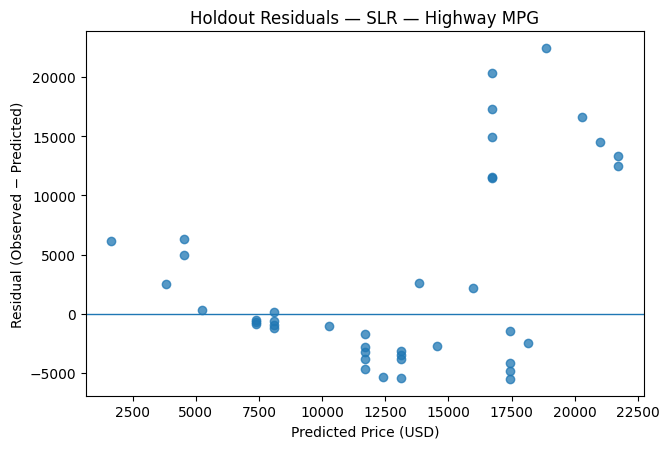

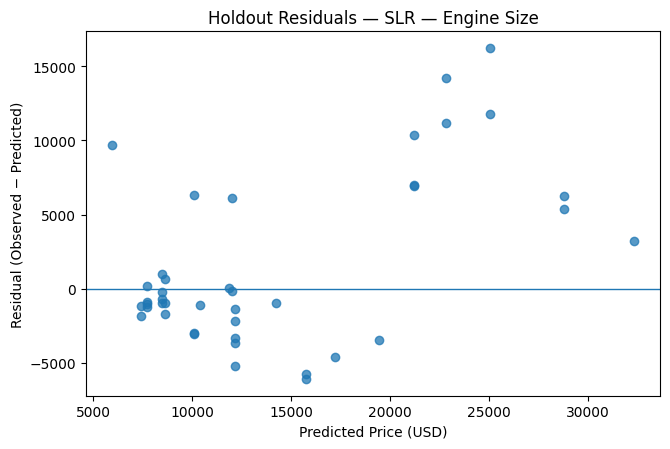

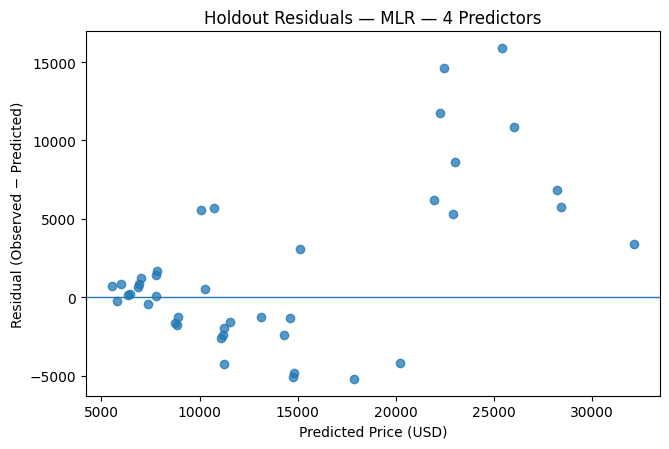

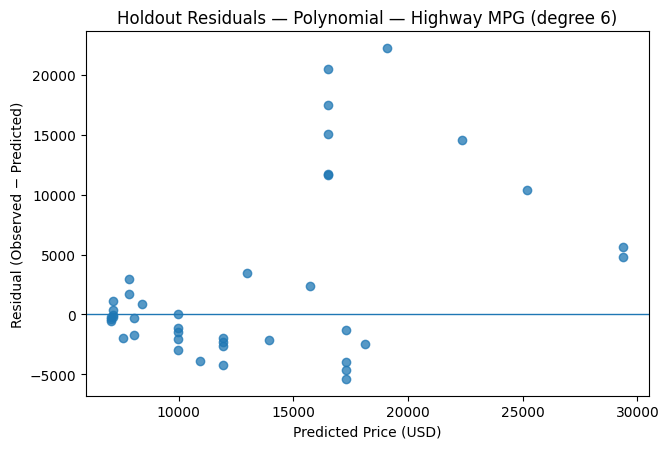

In [17]:
for name, test_pred in final_predictions.items():
    residuals = y_test.to_numpy() - test_pred

    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    ax.scatter(test_pred, residuals, alpha=0.75)
    ax.axhline(0, linewidth=1)

    ax.set_title(f"Holdout Residuals — {name}")
    ax.set_xlabel("Predicted Price (USD)")
    ax.set_ylabel("Residual (Observed − Predicted)")

    plt.tight_layout()
    plt.show()

# Part V — Model Selection

## 10. Selection criteria

The preferred final specification should demonstrate:

1. **strong holdout performance**;
2. **competitive cross-validation performance**;
3. **reasonable stability across folds**;
4. **limited evidence of overfitting**;
5. **parsimony and interpretability** appropriate to the analytical objective.

The goal is not to choose the most complicated model. It is to identify the regression specification that offers the strongest balance of explanatory usefulness and generalization.


In [18]:
best_test_model = final_comparison["Test R2"].idxmax()
best_cv_model = final_comparison["CV Mean R2"].idxmax()

print(f"Highest holdout R²: {best_test_model}")
print(f"Highest mean cross-validation R²: {best_cv_model}")
print(f"Selected polynomial degree: {int(best_degree)}")

if best_test_model == best_cv_model:
    print(
        "\nThe same model leads both the holdout and cross-validation comparisons, "
        "providing consistent evidence in favor of that specification."
    )
else:
    print(
        "\nThe holdout and cross-validation rankings differ. Model selection should "
        "therefore consider stability, error measures, parsimony, and the small sample "
        "size rather than relying on one split alone."
    )

Highest holdout R²: MLR — 4 Predictors
Highest mean cross-validation R²: MLR — 4 Predictors
Selected polynomial degree: 6

The same model leads both the holdout and cross-validation comparisons, providing consistent evidence in favor of that specification.


## 11. Final interpretation

The evaluation stage should be read together with the earlier notebooks:

- **Notebook 03** established which automobile characteristics are associated with price and highlighted overlap among several predictors.
- **Notebook 04** translated those relationships into SLR, MLR, and polynomial regression specifications.
- **Notebook 05** now evaluates both model generalization and the effect of polynomial complexity.

The final comparison therefore answers two separate regression questions:

1. **How much nonlinear structure can one predictor (`highway-mpg`) capture?**
2. **Does increasing nonlinear complexity in one predictor outperform a multiple regression using several meaningful automobile characteristics?**

That comparison is more informative than simply choosing the model with the highest in-sample R².

The multiple-regression specification retains a strong conceptual advantage because automobile price is unlikely to be represented fully by a single characteristic. However, the final choice should follow the combined evidence from cross-validation, holdout performance, stability, and parsimony rather than this expectation alone.

As throughout the project, the fitted coefficients describe associations in this historical sample rather than causal effects.


# 12. Project conclusion

Across the five-notebook workflow, the analysis demonstrates a complete regression-oriented Python project:

**Data Importing & Understanding → Data Cleaning & Feature Engineering → Exploratory Data Analysis → Regression Model Development → Regression Model Evaluation & Selection**

The main analytical lessons are:

- automobile price is strongly associated with vehicle power, engine capacity, physical size/weight, and fuel-economy characteristics;
- individual predictors can explain meaningful price variation, but no single variable captures the full pricing structure;
- combining several relevant predictors can substantially improve regression performance;
- nonlinear specifications may improve fit, but additional flexibility must be evaluated for overfitting;
- train/test evaluation and cross-validation provide more credible evidence than in-sample R² alone.

### Scope and limitations

This analysis uses a small historical automobile dataset. Its results should not be treated as a contemporary market-pricing model. Mean imputation, omitted brand/product attributes, predictor correlation, and the limited sample size also constrain interpretation.

Most importantly, the analysis identifies **associations**, not causal effects.

### Portfolio positioning

The final project is intentionally focused on **Python-based statistical analysis and regression modeling**. Its contribution is the disciplined progression from data quality and exploratory evidence to model specification, validation, and interpretation.
